In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

from data_utils import SegmentationData, label_img_to_rgb, get_train_transforms, compute_class_weights
from file_loader import get_all_files
from network.UNet import UNet
#from network.MultiResUNet import MultiResUNet
from create_borders import create_border_mask


#torch.set_default_tensor_type('torch.FloatTensor')
#set up default cuda device
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

In [2]:
data = 'segmentation_data/borders/'
files = get_all_files(data, 'png')
len(files)

1980

In [3]:
!python train_val_split.py

### Run this cell to find mean and standard deviation of train data

In [ ]:
train_data = SegmentationData(image_paths_file='segmentation_data/train.txt')
train_loader = torch.utils.data.DataLoader(train_data,
                                          batch_size=1,
                                          shuffle=True,
                                          num_workers=1)
nimages = 0
mean = 0.0
var = 0.0
for i,(inputs,targets) in enumerate(train_loader): #inputs must be tensor with values between (0,1) - to calculate mean and std
    batch = inputs
    # Rearrange batch to be the shape of [B, C, W * H]
    batch = batch.view(batch.size(0), batch.size(1), -1)
    nimages += batch.size(0)
    # Compute mean and std here
    mean += batch.mean(2).sum(0) 
    var += batch.var(2).sum(0)
mean /= nimages
var /= nimages
std = torch.sqrt(var)
print(nimages)                         
                               
print(mean)
print(std)

## Semantic Segmentation

Train size: 1584
Validation size: 396
Img size:  torch.Size([3, 120, 120])
Segmentation size:  torch.Size([120, 120])


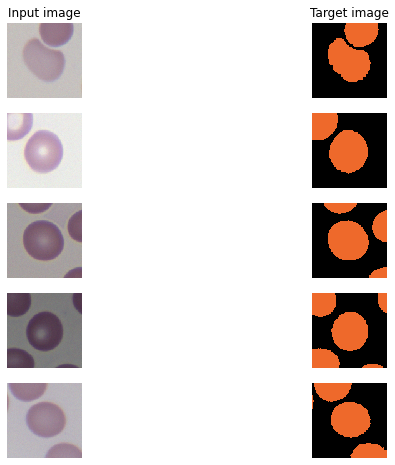

In [4]:
train_data = SegmentationData(image_paths_file='segmentation_data/train.txt', transforms=get_train_transforms())
val_data = SegmentationData(image_paths_file='segmentation_data/val.txt')

print("Train size: %i" % len(train_data))
print("Validation size: %i" % len(val_data))
print("Img size: ", train_data[0][0].size())
print("Segmentation size: ",train_data[0][1].size())

num_example_imgs = 5
for i, (img, target) in enumerate(train_data[:num_example_imgs]):
    # img
    plt.subplot(num_example_imgs, 2, i * 2 + 1)
    # unnormalize
    img[0] = img[0]*0.0779 + 0.6958
    img[1] = img[1]*0.1226 + 0.6409
    img[2] = img[2]*0.0763 + 0.6662
    plt.imshow(img.numpy().transpose(1,2,0))
    plt.axis('off')
    if i == 0:
        plt.title("Input image")
    
    # target
    plt.subplot(num_example_imgs, 2, i * 2 + 2)
    plt.imshow(label_img_to_rgb(target.numpy()))
    plt.axis('off')
    if i == 0:
        plt.title("Target image")
plt.show()

In [5]:
print('#### Test Case ###')
from torch.autograd import Variable

x = Variable(torch.rand(5,3,120,120)).to(device)
model = UNet(n_classes=2).to(device)
#param = count_param(model)
y = model(x)
print('Output shape:',y.shape)
#print('UNet totoal parameters: %.2fM (%d)'%(param/1e6,param))

#### Test Case ###
Output shape: torch.Size([5, 2, 120, 120])


In [6]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

7764098

START TRAIN.
[Iteration 20/4950] TRAIN loss: 0.880
[Iteration 40/4950] TRAIN loss: 0.339
[Iteration 60/4950] TRAIN loss: 0.142
[Iteration 80/4950] TRAIN loss: 0.114
[Epoch 1/50] TRAIN acc/loss: 0.973/0.114
[Epoch 1/50] VAL   acc/loss: 0.980/0.088
[Iteration 119/4950] TRAIN loss: 0.096
[Iteration 139/4950] TRAIN loss: 0.097
[Iteration 159/4950] TRAIN loss: 0.085
[Iteration 179/4950] TRAIN loss: 0.074
[Epoch 2/50] TRAIN acc/loss: 0.978/0.074
[Epoch 2/50] VAL   acc/loss: 0.984/0.067
[Iteration 218/4950] TRAIN loss: 0.078
[Iteration 238/4950] TRAIN loss: 0.070
[Iteration 258/4950] TRAIN loss: 0.073
[Iteration 278/4950] TRAIN loss: 0.074
[Epoch 3/50] TRAIN acc/loss: 0.984/0.074
[Epoch 3/50] VAL   acc/loss: 0.984/0.063
[Iteration 317/4950] TRAIN loss: 0.067
[Iteration 337/4950] TRAIN loss: 0.065
[Iteration 357/4950] TRAIN loss: 0.069
[Iteration 377/4950] TRAIN loss: 0.072
[Epoch 4/50] TRAIN acc/loss: 0.982/0.072
[Epoch 4/50] VAL   acc/loss: 0.985/0.058
[Iteration 416/4950] TRAIN loss: 0.063


[Epoch 34/50] VAL   acc/loss: 0.989/0.045
[Iteration 3386/4950] TRAIN loss: 0.050
[Iteration 3406/4950] TRAIN loss: 0.048
[Iteration 3426/4950] TRAIN loss: 0.050
[Iteration 3446/4950] TRAIN loss: 0.053
[Epoch 35/50] TRAIN acc/loss: 0.988/0.053
[Epoch 35/50] VAL   acc/loss: 0.988/0.049
[Iteration 3485/4950] TRAIN loss: 0.049
[Iteration 3505/4950] TRAIN loss: 0.050
[Iteration 3525/4950] TRAIN loss: 0.050
[Iteration 3545/4950] TRAIN loss: 0.052
[Epoch 36/50] TRAIN acc/loss: 0.989/0.052
[Epoch 36/50] VAL   acc/loss: 0.989/0.045
[Iteration 3584/4950] TRAIN loss: 0.049
[Iteration 3604/4950] TRAIN loss: 0.053
[Iteration 3624/4950] TRAIN loss: 0.050
[Iteration 3644/4950] TRAIN loss: 0.051
[Epoch 37/50] TRAIN acc/loss: 0.990/0.051
[Epoch 37/50] VAL   acc/loss: 0.989/0.048
[Iteration 3683/4950] TRAIN loss: 0.049
[Iteration 3703/4950] TRAIN loss: 0.048
[Iteration 3723/4950] TRAIN loss: 0.051
[Iteration 3743/4950] TRAIN loss: 0.051
[Epoch 38/50] TRAIN acc/loss: 0.988/0.051
[Epoch 38/50] VAL   acc/

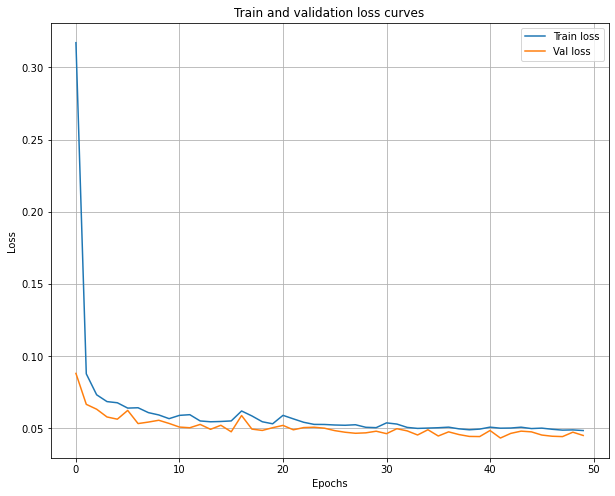

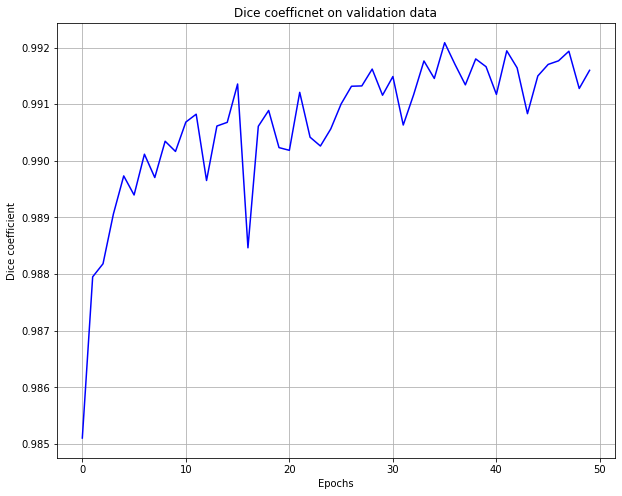

In [7]:
from solver import Solver
import torch.nn.functional as F

train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True, num_workers=1)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=2, shuffle=False, num_workers=1)

model = UNet(n_classes=2)
model.to(device)
class_weights = compute_class_weights(train_data, 2)   
         
solver = Solver(optim_args={"lr": 1e-4, "weight_decay": 0.001}, class_weights = class_weights)
                
solver.train(model, train_loader, val_loader, log_nth=20, num_epochs=50)

In [ ]:
model.save("models/unet_50_rs_2_c_2_no_test_final.model")

## Visualization on validation data

In [9]:
model = torch.load("models/unet_50_rs_2_c_2_no_test_final.model")

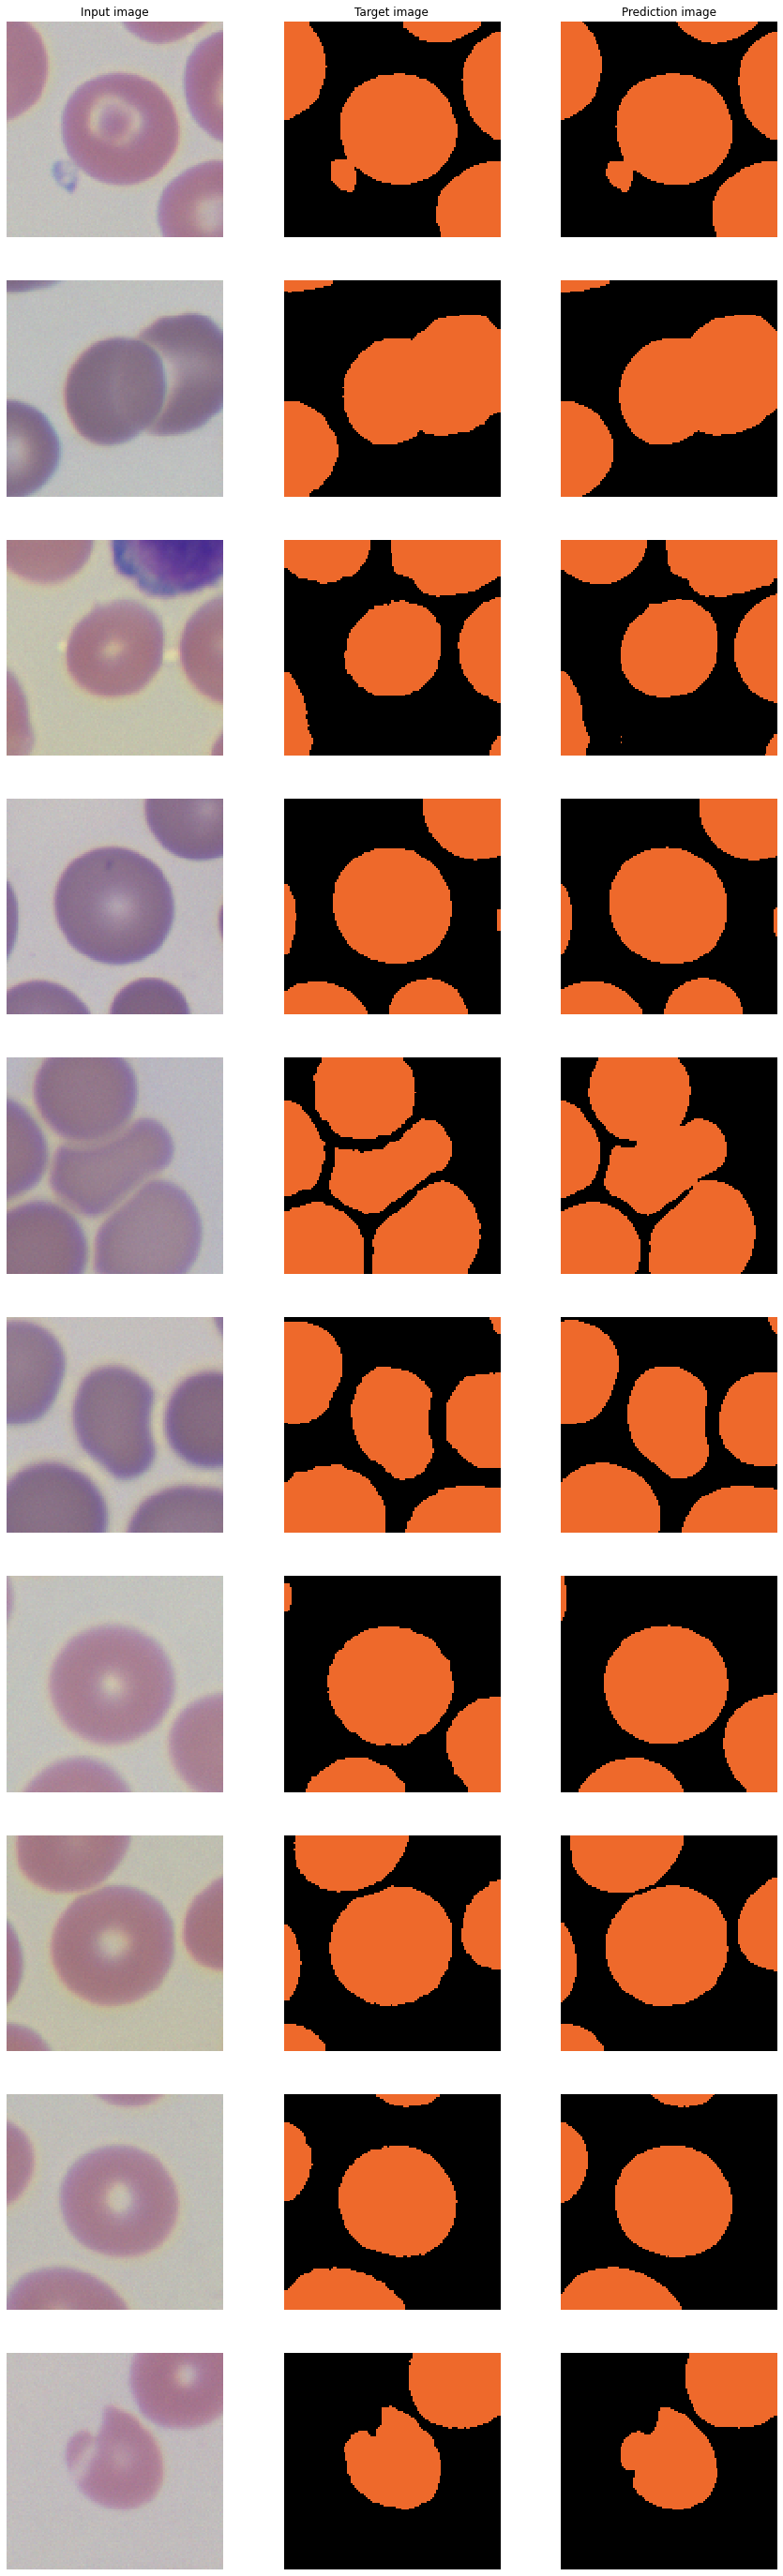

In [10]:
num_example_imgs = 10
plt.figure(figsize=(15, 5 * num_example_imgs))
model.eval()

for i, (img, target) in enumerate(val_data[10:num_example_imgs+10]):
    inputs = img.unsqueeze(0)
    inputs = inputs.to(device)
    
    outputs = model.forward(inputs)
    _, preds = torch.max(outputs, 1)
    pred = preds[0].data.cpu()
    
    img, target, pred = img.numpy(), target.numpy(), pred.numpy()
    
    # img
    plt.subplot(num_example_imgs, 3, i * 3 + 1)
    plt.axis('off')
    # Unnormalize  to [0,1]
    img[0] = img[0]*0.0779 + 0.6958
    img[1] = img[1]*0.1226 + 0.6409
    img[2] = img[2]*0.0763 + 0.6662
    plt.imshow(img.transpose(1,2,0))
    if i == 0:
        plt.title("Input image")
    
    # target
    plt.subplot(num_example_imgs, 3, i * 3 + 2)
    plt.axis('off')
    plt.imshow(label_img_to_rgb(target))
    if i == 0:
        plt.title("Target image")

    # pred
    plt.subplot(num_example_imgs, 3, i * 3 + 3)
    plt.axis('off')
    plt.imshow(label_img_to_rgb(pred))
    if i == 0:
        plt.title("Prediction image")
        
model.train()    
plt.show()

##  Border Segmentation

In [ ]:
## Creating Ground Truth border images
targets = 'segmentation_data/targets/'
files = get_all_files(targets, 'png')
create_border_mask(files)


Train size: 1584
Validation size: 396
Img size:  torch.Size([3, 120, 120])
Segmentation size:  torch.Size([120, 120])


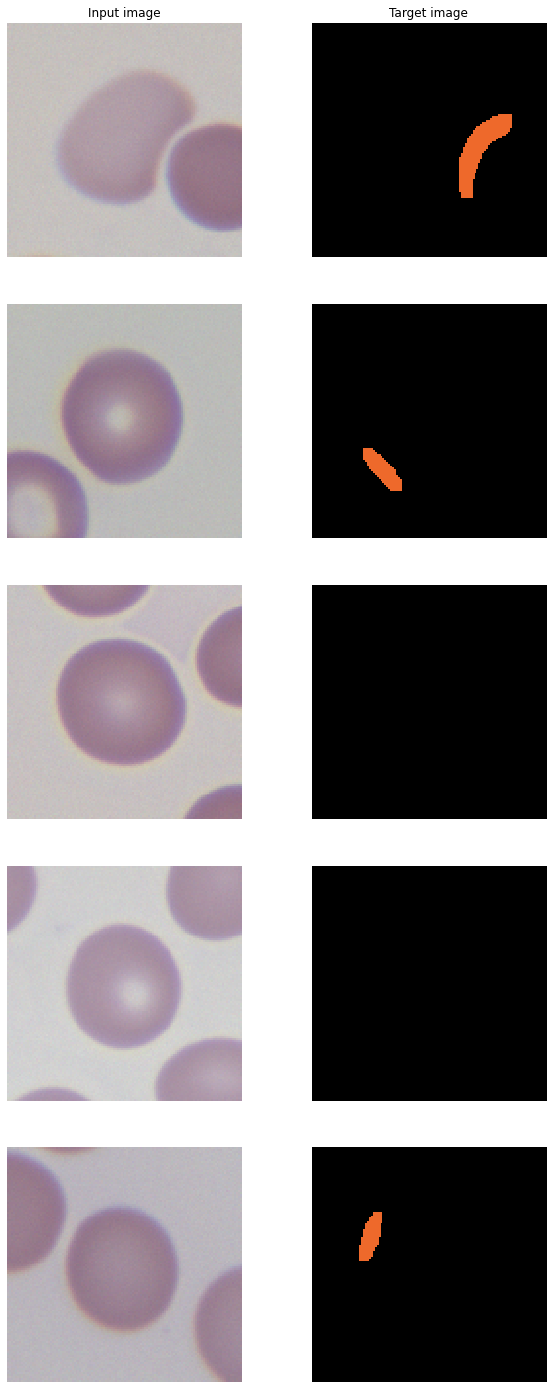

In [11]:
train_data = SegmentationData(image_paths_file='segmentation_data/train.txt', transforms=get_train_transforms(), border_detection = True)
val_data = SegmentationData(image_paths_file='segmentation_data/val.txt', border_detection = True)

print("Train size: %i" % len(train_data))
print("Validation size: %i" % len(val_data))
print("Img size: ", train_data[0][0].size())
print("Segmentation size: ",train_data[0][1].size())

num_example_imgs = 5
plt.figure(figsize=(10, 5 * num_example_imgs))
for i, (img, target) in enumerate(train_data[:num_example_imgs]):
    # img
    plt.subplot(num_example_imgs, 2, i * 2 + 1)
    # unnormalize
    img[0] = img[0]*0.0779 + 0.6958
    img[1] = img[1]*0.1226 + 0.6409
    img[2] = img[2]*0.0763 + 0.6662

    plt.imshow(img.numpy().transpose(1,2,0))
    plt.axis('off')
    if i == 0:
        plt.title("Input image")
    
    # target
    plt.subplot(num_example_imgs, 2, i * 2 + 2)
    plt.imshow(label_img_to_rgb(target.numpy()))
    plt.axis('off')
    if i == 0:
        plt.title("Target image")
plt.show()

START TRAIN.
[Iteration 20/4950] TRAIN loss: 1.598
[Iteration 40/4950] TRAIN loss: 1.406
[Iteration 60/4950] TRAIN loss: 1.276
[Iteration 80/4950] TRAIN loss: 1.202
[Epoch 1/50] TRAIN acc/loss: 0.961/1.202
[Epoch 1/50] VAL   acc/loss: 0.955/0.939
[Iteration 119/4950] TRAIN loss: 1.033
[Iteration 139/4950] TRAIN loss: 1.002
[Iteration 159/4950] TRAIN loss: 0.982
[Iteration 179/4950] TRAIN loss: 0.895
[Epoch 2/50] TRAIN acc/loss: 0.964/0.895
[Epoch 2/50] VAL   acc/loss: 0.973/0.806
[Iteration 218/4950] TRAIN loss: 0.948
[Iteration 238/4950] TRAIN loss: 0.859
[Iteration 258/4950] TRAIN loss: 0.868
[Iteration 278/4950] TRAIN loss: 0.859
[Epoch 3/50] TRAIN acc/loss: 0.945/0.859
[Epoch 3/50] VAL   acc/loss: 0.970/0.762
[Iteration 317/4950] TRAIN loss: 0.854
[Iteration 337/4950] TRAIN loss: 0.834
[Iteration 357/4950] TRAIN loss: 0.844
[Iteration 377/4950] TRAIN loss: 0.741
[Epoch 4/50] TRAIN acc/loss: 0.974/0.741
[Epoch 4/50] VAL   acc/loss: 0.979/0.729
[Iteration 416/4950] TRAIN loss: 0.707


[Epoch 34/50] VAL   acc/loss: 0.987/0.573
[Iteration 3386/4950] TRAIN loss: 0.599
[Iteration 3406/4950] TRAIN loss: 0.571
[Iteration 3426/4950] TRAIN loss: 0.564
[Iteration 3446/4950] TRAIN loss: 0.614
[Epoch 35/50] TRAIN acc/loss: 0.990/0.614
[Epoch 35/50] VAL   acc/loss: 0.988/0.577
[Iteration 3485/4950] TRAIN loss: 0.570
[Iteration 3505/4950] TRAIN loss: 0.581
[Iteration 3525/4950] TRAIN loss: 0.567
[Iteration 3545/4950] TRAIN loss: 0.570
[Epoch 36/50] TRAIN acc/loss: 0.995/0.570
[Epoch 36/50] VAL   acc/loss: 0.987/0.566
[Iteration 3584/4950] TRAIN loss: 0.589
[Iteration 3604/4950] TRAIN loss: 0.583
[Iteration 3624/4950] TRAIN loss: 0.599
[Iteration 3644/4950] TRAIN loss: 0.551
[Epoch 37/50] TRAIN acc/loss: 0.991/0.551
[Epoch 37/50] VAL   acc/loss: 0.988/0.577
[Iteration 3683/4950] TRAIN loss: 0.588
[Iteration 3703/4950] TRAIN loss: 0.569
[Iteration 3723/4950] TRAIN loss: 0.623
[Iteration 3743/4950] TRAIN loss: 0.586
[Epoch 38/50] TRAIN acc/loss: 0.989/0.586
[Epoch 38/50] VAL   acc/

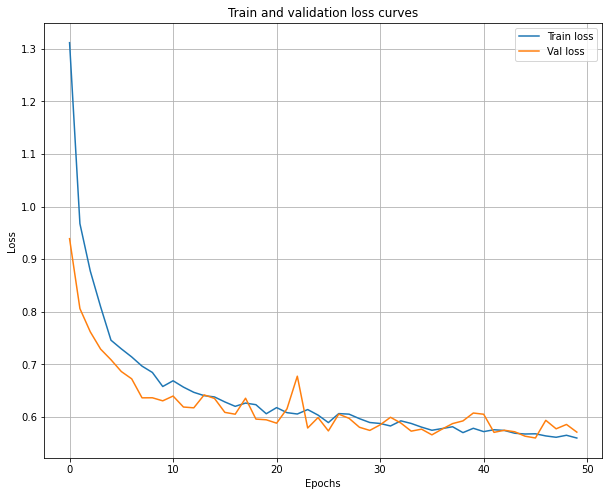

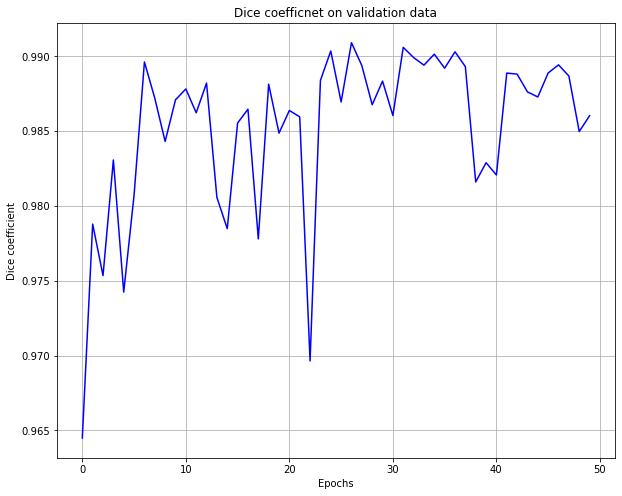

In [12]:
from solver import Solver
train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True, num_workers=1)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=2, shuffle=False, num_workers=1)

model2 = UNet(n_classes=2)
model2.to(device)
class_weights = compute_class_weights(train_data, 2)  # num_classes = 2 

solver = Solver(optim_args={"lr": 1e-4, "weight_decay": 0.001}, class_weights = class_weights) 
solver.train(model2, train_loader, val_loader, log_nth=20, num_epochs=50)

In [ ]:
model2.save("models/unet_border_50_rs_2_platelet_no_test_final.model")

In [13]:
model2 = torch.load("models/unet_border_50_rs_2_platelet_no_test_final.model")

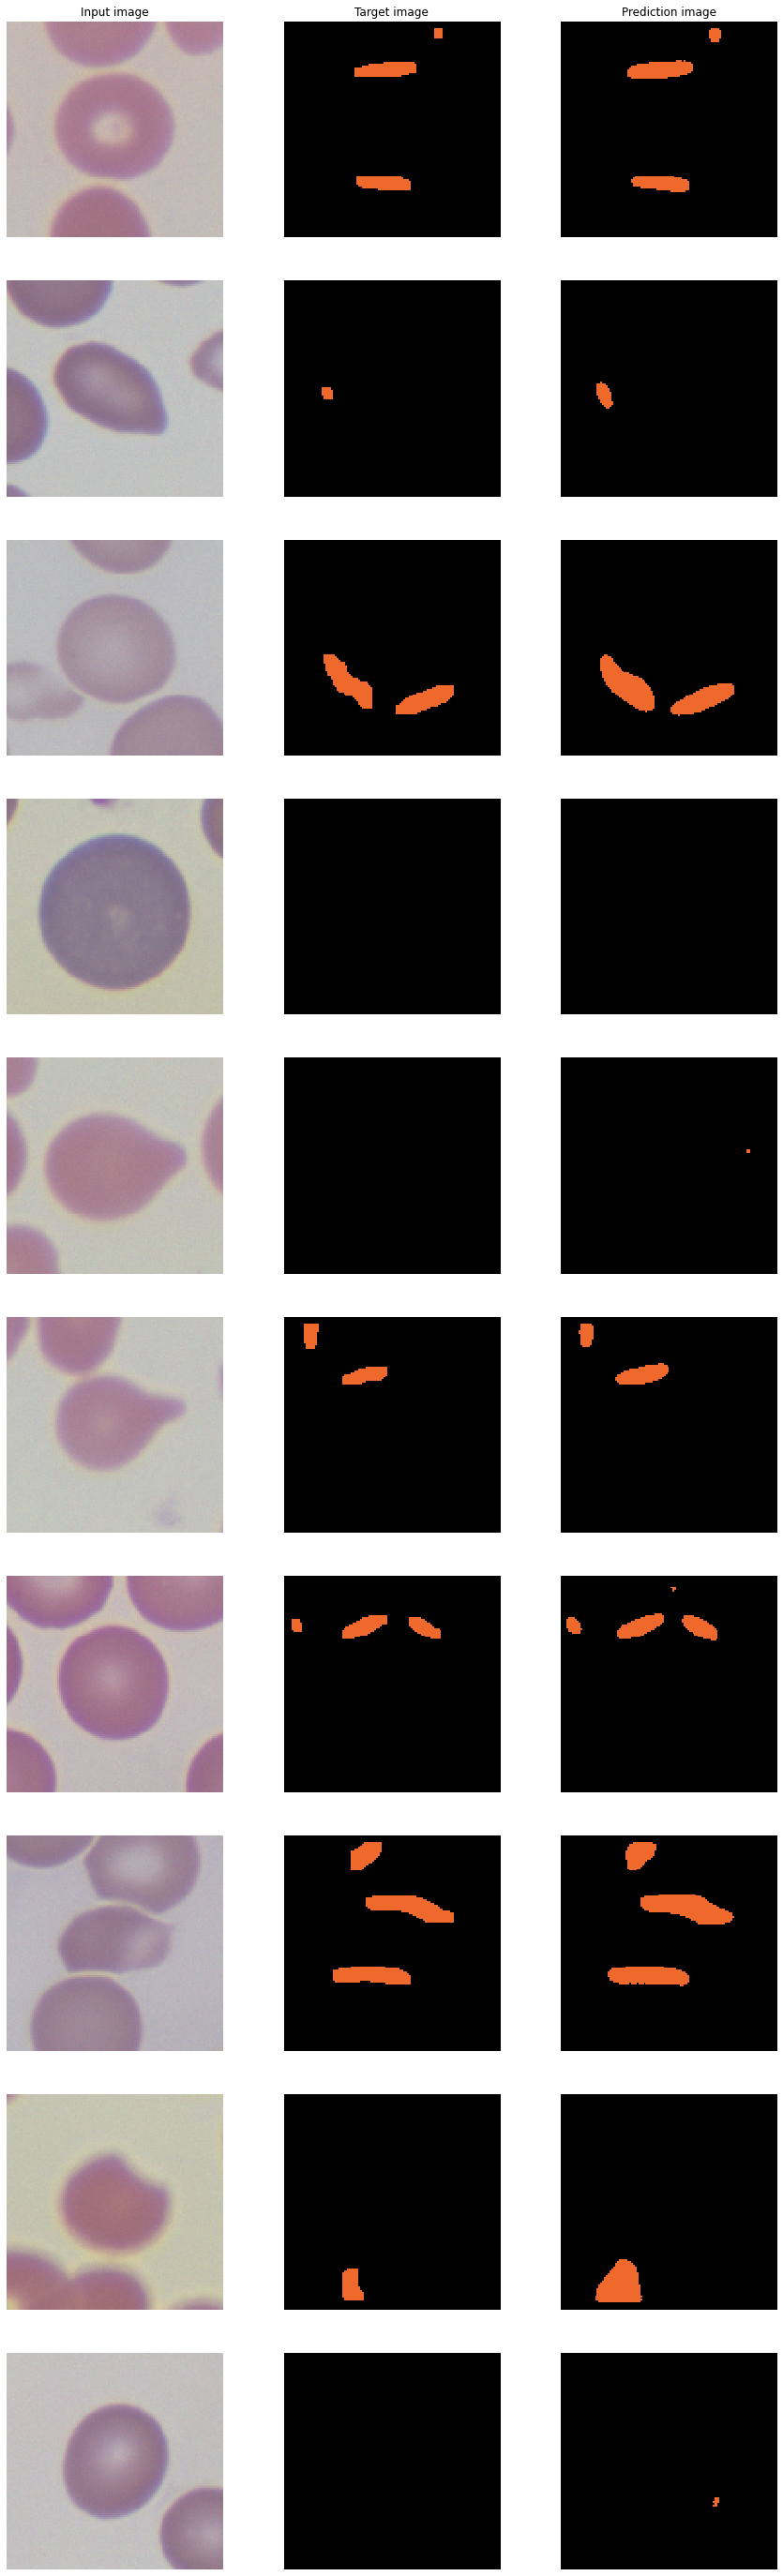

In [14]:
num_example_imgs = 10
plt.figure(figsize=(15, 5 * num_example_imgs))

model2.eval()
for i, (img, target) in enumerate(val_data[:num_example_imgs]):
    inputs = img.unsqueeze(0)
    inputs = inputs.to(device)
    
    outputs = model2.forward(inputs)
    _, preds = torch.max(outputs, 1)
    pred = preds[0].data.cpu()
    
    img, target, pred = img.numpy(), target.numpy(), pred.numpy()
    
    # img
    plt.subplot(num_example_imgs, 3, i * 3 + 1)
    plt.axis('off')
    # unnormalize
    img[0] = img[0]*0.0779 + 0.6958
    img[1] = img[1]*0.1226 + 0.6409
    img[2] = img[2]*0.0763 + 0.6662
    plt.imshow(img.transpose(1,2,0))
    if i == 0:
        plt.title("Input image")
    
    # target
    plt.subplot(num_example_imgs, 3, i * 3 + 2)
    plt.axis('off')
    plt.imshow(label_img_to_rgb(target))
    if i == 0:
        plt.title("Target image")

    # pred
    plt.subplot(num_example_imgs, 3, i * 3 + 3)
    plt.axis('off')
    plt.imshow(label_img_to_rgb(pred))
    if i == 0:
        plt.title("Prediction image")

model2.train()
plt.show()